<a href="https://colab.research.google.com/github/parisarahman/music-generation-unsupervised/blob/main/CSE425_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install pretty_midi miditok music21


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 49.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 88.1 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=6db1831b11425f83855ca6fcf5950ac3eef963b5783b98b7c9805de5ca4b8349
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [5]:
import os
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [6]:
DATASET_PATH = '/content/drive/MyDrive/maestro/maestro-v3.0.0'
CSV_PATH = os.path.join(DATASET_PATH, 'maestro-v3.0.0.csv')

In [ ]:
metadata = pd.read_csv(CSV_PATH)

print(metadata.head())
print(metadata.columns)

   canonical_composer                canonical_title       split  year  \
0          Alban Berg                   Sonata Op. 1       train  2018   
1          Alban Berg                   Sonata Op. 1       train  2008   
2          Alban Berg                   Sonata Op. 1       train  2017   
3  Alexander Scriabin  24 Preludes Op. 11, No. 13-24       train  2004   
4  Alexander Scriabin               3 Etudes, Op. 65  validation  2006   

                                       midi_filename  \
0  2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...   
1  2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...   
2  2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...   
3  2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...   
4  2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...   

                                      audio_filename    duration  
0  2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...  698.661160  
1  2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...  759.518471  
2  2017/MIDI-Unpr

In [ ]:
train_df = metadata[metadata['split'] == 'train']
val_df = metadata[metadata['split'] == 'validation']
test_df = metadata[metadata['split'] == 'test']

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))

Train: 962
Validation: 137
Test: 177


In [ ]:
sample_path = os.path.join(DATASET_PATH, train_df.iloc[0]['midi_filename'])
print(sample_path)
print(os.path.exists(sample_path))

/content/drive/MyDrive/maestro/maestro-v3.0.0/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
True


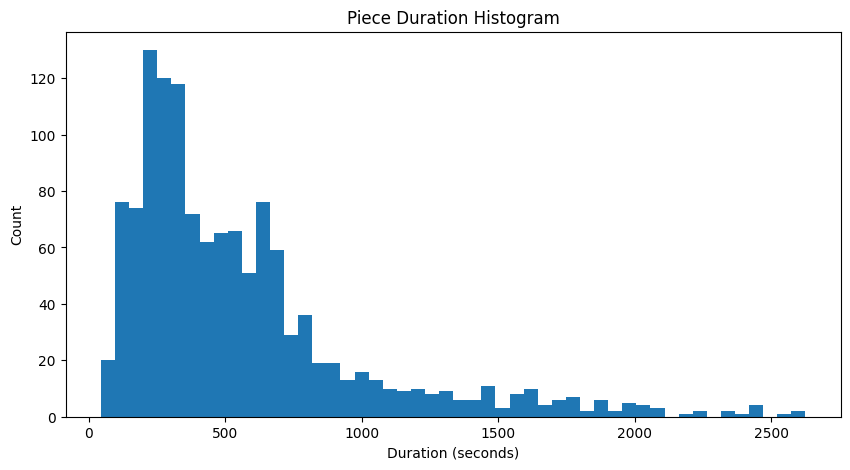

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(metadata['duration'], bins=50)
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.title('Piece Duration Histogram')
plt.show()

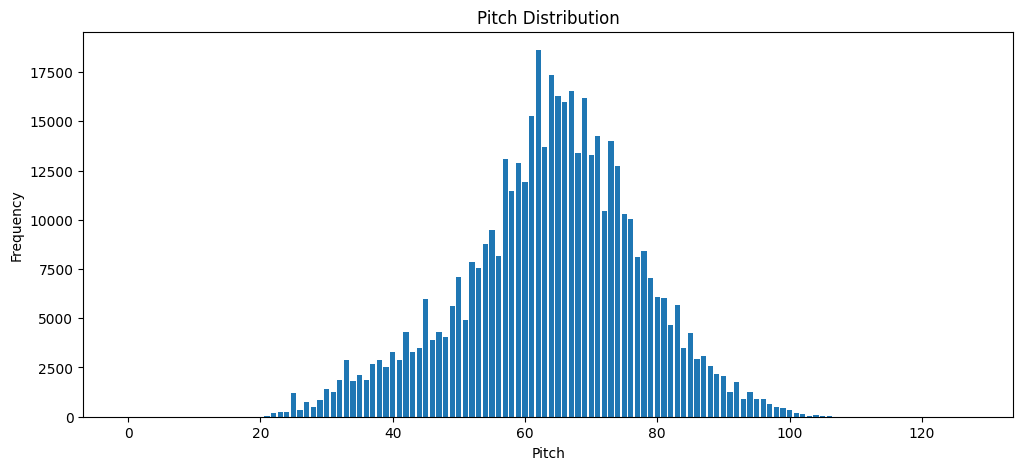

In [ ]:
pitch_counts = np.zeros(128)

sample_files = train_df['midi_filename'].tolist()[:100]

for file in sample_files:
    path = os.path.join(DATASET_PATH, file)

    try:
        midi_data = pretty_midi.PrettyMIDI(path)

        for instrument in midi_data.instruments:
            for note in instrument.notes:
                pitch_counts[note.pitch] += 1
    except:
        continue

plt.figure(figsize=(12,5))
plt.bar(range(128), pitch_counts)
plt.xlabel('Pitch')
plt.ylabel('Frequency')
plt.title('Pitch Distribution')
plt.show()

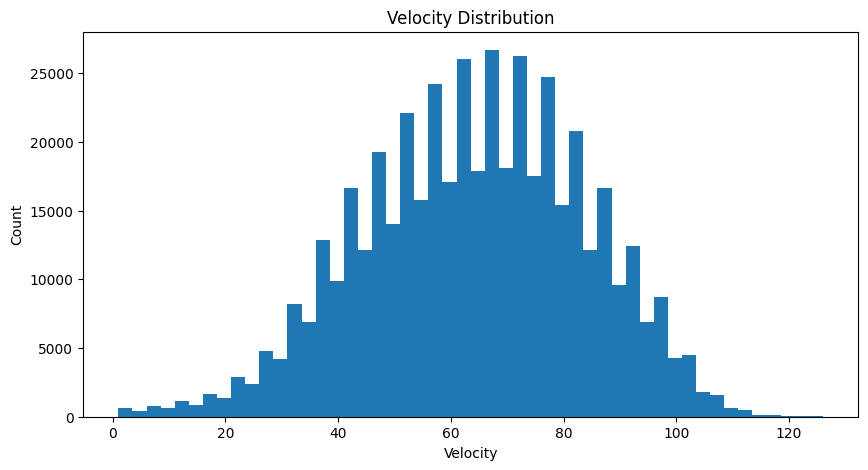

In [ ]:
velocities = []

for file in sample_files:
    path = os.path.join(DATASET_PATH, file)

    try:
        midi_data = pretty_midi.PrettyMIDI(path)

        for instrument in midi_data.instruments:
            for note in instrument.notes:
                velocities.append(note.velocity)

    except:
        continue
plt.figure(figsize=(10,5))
plt.hist(velocities, bins=50)
plt.xlabel('Velocity')
plt.ylabel('Count')
plt.title('Velocity Distribution')
plt.show()

In [ ]:
FS = 16
WINDOW_SIZE = 128

def midi_to_pianoroll(path, fs=FS):

    midi_data = pretty_midi.PrettyMIDI(path)

    piano_roll = midi_data.get_piano_roll(fs=fs)

    piano_roll = piano_roll[21:109]

    piano_roll = (piano_roll > 0).astype(np.float32)

    piano_roll = piano_roll.T

    return piano_roll

In [ ]:
sample_roll = midi_to_pianoroll(sample_path)

print(sample_roll.shape)

(11263, 88)


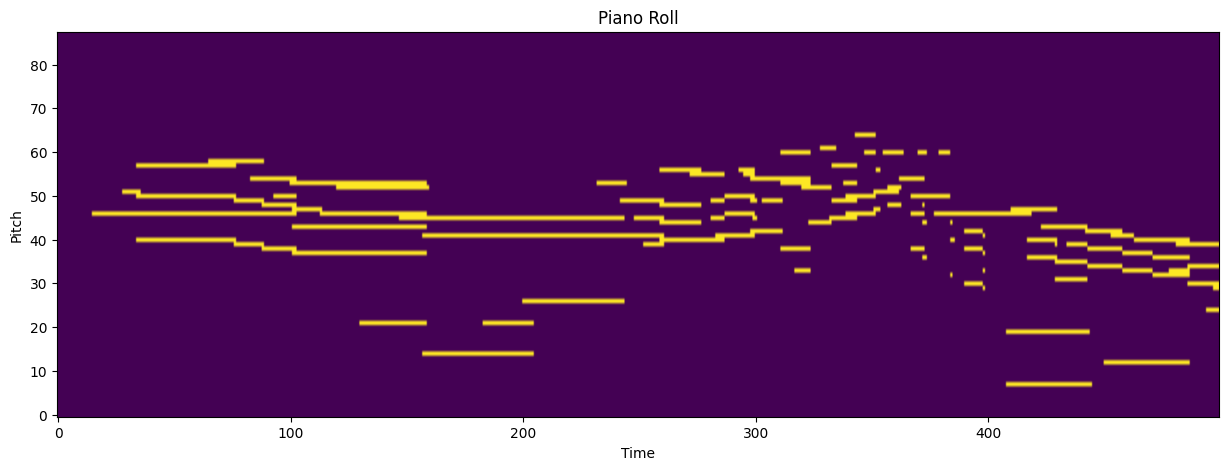

In [ ]:
plt.figure(figsize=(15,5))
plt.imshow(sample_roll[:500].T, aspect='auto', origin='lower')
plt.xlabel('Time')
plt.ylabel('Pitch')
plt.title('Piano Roll')
plt.show()

In [ ]:
nonzero = np.count_nonzero(sample_roll)
total = sample_roll.size

sparsity = 1 - (nonzero / total)

print('Sparsity:', sparsity)

Sparsity: 0.9278066557432624


In [ ]:
def create_windows(piano_roll, window_size=128):

    windows = []

    total_steps = piano_roll.shape[0]

    for start in range(0, total_steps - window_size, window_size):

        window = piano_roll[start:start + window_size]

        active_ratio = np.count_nonzero(window) / window.size

        if active_ratio > 0.02:
          windows.append(window)

    return windows

In [ ]:
train_windows = []

files = train_df['midi_filename'].tolist()

for idx, file in enumerate(files):

    path = os.path.join(DATASET_PATH, file)

    try:
        piano_roll = midi_to_pianoroll(path)

        windows = create_windows(piano_roll)

        train_windows.extend(windows)

    except Exception as e:
        print('Error:', file)

    if idx % 50 == 0:
        print(idx)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


In [ ]:
train_windows = np.array(train_windows)

print(train_windows.shape)

(62684, 128, 88)


In [ ]:
SAVE_PATH = '/content/drive/MyDrive/maestro/'

os.makedirs(SAVE_PATH, exist_ok=True)

np.save(os.path.join(SAVE_PATH, 'train_windows.npy'), train_windows)

In [ ]:
class PianoRollDataset(Dataset):

    def __init__(self, npy_path):

        self.data = np.load(npy_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        return torch.tensor(sample, dtype=torch.float32)

In [ ]:
class PianoRollDataset(Dataset):

    def __init__(self, npy_path):

        self.data = np.load(npy_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        return torch.tensor(sample, dtype=torch.float32)

# **LSTM AUTOENCODER**

In [ ]:
class LSTMAutoencoder(nn.Module):

    def __init__(self,
                 input_dim=88,
                 hidden_dim=256,
                 latent_dim=64,
                 num_layers=2):

        super().__init__()

        self.encoder = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.to_latent = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.LSTM(
            latent_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):

        _, (h_n, _) = self.encoder(x)

        latent = self.to_latent(h_n[-1])

        repeated = latent.unsqueeze(1).repeat(1, x.size(1), 1)

        decoded, _ = self.decoder(repeated)

        output = self.output_layer(decoded)

        return output

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = LSTMAutoencoder().to(device)

In [ ]:
pos_weight = torch.tensor([20.0]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [ ]:
#train_windows

NameError: name 'train_windows' is not defined

In [ ]:
class PianoRollDataset(Dataset):

    def __init__(self, data):

        self.data = torch.tensor(
            data,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        return self.data[idx]

In [ ]:
train_windows_small = train_windows[:2000]

In [ ]:
train_dataset = PianoRollDataset(
    train_windows_small
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
for batch in train_loader:

    print(batch.shape)

    break

torch.Size([64, 128, 88])


In [ ]:
EPOCHS = 20

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        outputs = model(batch)

        loss = criterion(outputs, batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f'Epoch {epoch+1} Loss: {avg_loss}')

Epoch 1 Loss: 1.318404383957386
Epoch 2 Loss: 1.321680024266243
Epoch 3 Loss: 1.316495943814516
Epoch 4 Loss: 1.320703163743019
Epoch 5 Loss: 1.3133858889341354
Epoch 6 Loss: 1.313335482031107
Epoch 7 Loss: 1.3134578056633472
Epoch 8 Loss: 1.3128300048410892
Epoch 9 Loss: 1.3265750110149384
Epoch 10 Loss: 1.3147576339542866
Epoch 11 Loss: 1.314100757241249
Epoch 12 Loss: 1.319417517632246
Epoch 13 Loss: 1.3153760880231857
Epoch 14 Loss: 1.313469298183918
Epoch 15 Loss: 1.3142011538147926
Epoch 16 Loss: 1.3143838495016098
Epoch 17 Loss: 1.316905491054058
Epoch 18 Loss: 1.3150047212839127
Epoch 19 Loss: 1.3160224109888077
Epoch 20 Loss: 1.3151154555380344


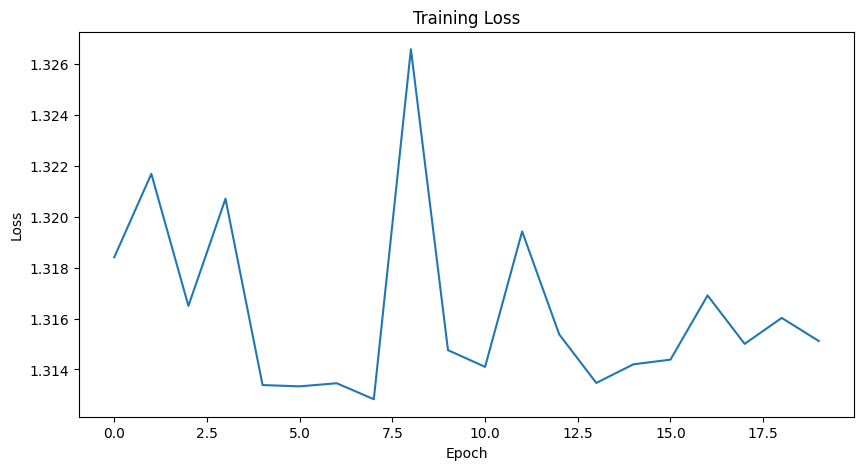

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/maestro/lstm_autoencoder.pth')

In [ ]:
model.eval()

with torch.no_grad():

    z = torch.randn(1, 64).to(device)

    repeated = z.unsqueeze(1).repeat(1, 128, 1)

    decoded, _ = model.decoder(repeated)

    output = model.output_layer(decoded)

    probs = torch.sigmoid(output)

    generated = (probs > 0.35).float()

In [ ]:

def pianoroll_to_midi(piano_roll, output_path, fs=16):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)
    time_per_step = 1 / fs

    for pitch in range(88):
        active = False
        note_start = 0

        for t in range(len(piano_roll)):
            value = piano_roll[t, pitch]

            if value == 1 and not active:
                active = True
                note_start = t * time_per_step

            elif value == 0 and active:
                active = False
                note_end = t * time_per_step
                if note_end > note_start:
                    instrument.notes.append(
                        pretty_midi.Note(
                            velocity=80,
                            pitch=pitch + 21,
                            start=note_start,
                            end=note_end
                        )
                    )


        if active:
            note_end = len(piano_roll) * time_per_step
            instrument.notes.append(
                pretty_midi.Note(
                    velocity=80,
                    pitch=pitch + 21,
                    start=note_start,
                    end=note_end
                )
            )

    midi.instruments.append(instrument)
    midi.write(output_path)

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/maestro/lstm_samples', exist_ok=True)

model.eval()

for i in range(5):
    with torch.no_grad():
        z = torch.randn(1, 64).to(device)
        repeated = z.unsqueeze(1).repeat(1, 128, 1)
        decoded, _ = model.decoder(repeated)
        output = model.output_layer(decoded)
        probs = torch.sigmoid(output)

        print(f"Sample {i} | Max: {probs.max():.3f} | Notes>0.2: {(probs > 0.2).sum().item()}")

        generated = (probs > 0.2).float()

    roll = generated.squeeze(0).cpu().numpy()

    pianoroll_to_midi(
        roll,
        f'/content/drive/MyDrive/maestro/lstm_samples/lstm_sample_{i}.mid'
    )
    print(f'Saved sample {i}')




Sample 0 | Max: 0.886 | Notes>0.2: 8991
Saved sample 0
Sample 1 | Max: 0.894 | Notes>0.2: 11264
Saved sample 1
Sample 2 | Max: 0.886 | Notes>0.2: 9019
Saved sample 2
Sample 3 | Max: 0.886 | Notes>0.2: 9092
Saved sample 3
Sample 4 | Max: 0.886 | Notes>0.2: 9016
Saved sample 4


In [ ]:
generated_roll = generated.squeeze(0).cpu().numpy()

pianoroll_to_midi(
    generated_roll,
    '/content/drive/MyDrive/maestro/lstm_generated_sample.mid'
)
print("MIDI saved!")

MIDI saved!


In [30]:
def pitch_histogram(midi_path):
    midi = pretty_midi.PrettyMIDI(midi_path)
    histogram = np.zeros(12)
    total_notes = 0
    for instrument in midi.instruments:
        for note in instrument.notes:
            histogram[note.pitch % 12] += 1
            total_notes += 1
    if total_notes > 0:
        histogram /= total_notes
    return histogram

def pitch_histogram_similarity(real_midi, generated_midi):
    p = pitch_histogram(real_midi)
    q = pitch_histogram(generated_midi)
    return np.sum(np.abs(p - q))

def rhythm_diversity(midi_path):
    midi = pretty_midi.PrettyMIDI(midi_path)
    durations = [round((n.end - n.start) / 0.05) * 0.05
                 for inst in midi.instruments for n in inst.notes]
    if not durations:
        return 0
    return len(set(durations)) / len(durations)

def repetition_ratio(midi_path, n=4):
    midi = pretty_midi.PrettyMIDI(midi_path)
    pitches = [note.pitch for inst in midi.instruments
               for note in sorted(inst.notes, key=lambda x: x.start)]
    patterns = [tuple(pitches[i:i+n]) for i in range(len(pitches) - n)]
    if not patterns:
        return 0
    counts = {}
    for p in patterns:
        counts[p] = counts.get(p, 0) + 1
    return sum(1 for v in counts.values() if v > 1) / len(patterns)

print("Metric functions defined!")

Metric functions defined!


In [31]:
real_midi = "/content/drive/MyDrive/maestro/markov.mid"
lstm_midi = "/content/drive/MyDrive/maestro/lstm_generated_sample.mid"

In [32]:
p_real = pitch_histogram(real_midi)
p_lstm = pitch_histogram(lstm_midi)

In [33]:
import numpy as np

lstm_distance = np.sum(np.abs(p_real - p_lstm))
print("LSTM Pitch Histogram Distance:", lstm_distance)

LSTM Pitch Histogram Distance: 0.2827272727272727


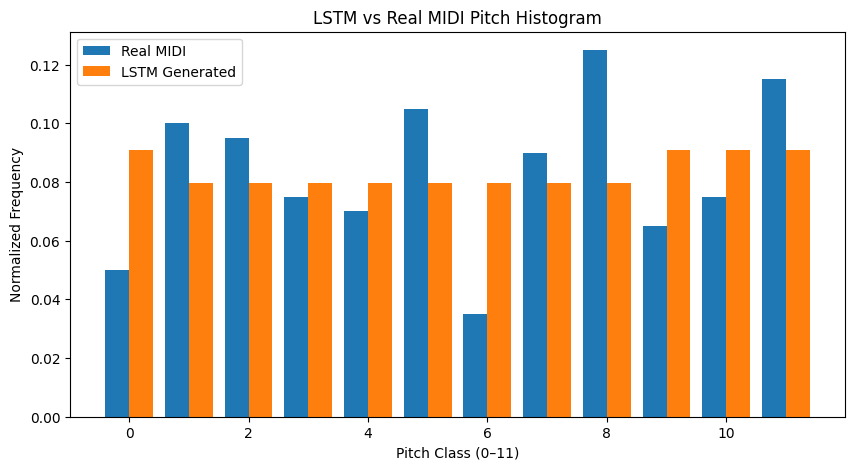

In [34]:
import matplotlib.pyplot as plt

x = np.arange(12)

plt.figure(figsize=(10,5))

plt.bar(x - 0.2, p_real, width=0.4, label="Real MIDI")
plt.bar(x + 0.2, p_lstm, width=0.4, label="LSTM Generated")

plt.xlabel("Pitch Class (0–11)")
plt.ylabel("Normalized Frequency")
plt.title("LSTM vs Real MIDI Pitch Histogram")
plt.legend()

plt.show()

In [ ]:

real_file = sample_path

lstm_ph, lstm_rd, lstm_rr = [], [], []

for i in range(5):
    path = f'/content/drive/MyDrive/maestro/lstm_samples/lstm_sample_{i}.mid'
    lstm_ph.append(pitch_histogram_similarity(real_file, path))
    lstm_rd.append(rhythm_diversity(path))
    lstm_rr.append(repetition_ratio(path))

print(f'LSTM AE Pitch Similarity: {np.mean(lstm_ph):.4f}')
print(f'LSTM AE Rhythm Diversity: {np.mean(lstm_rd):.4f}')
print(f'LSTM AE Repetition Ratio: {np.mean(lstm_rr):.4f}')

LSTM AE Pitch Similarity: 0.0882
LSTM AE Rhythm Diversity: 0.0659
LSTM AE Repetition Ratio: 0.0000


# **VARIATIONAL AUTOENCODER**

In [51]:
class LSTMVAE(nn.Module):

    def __init__(self,
                 input_dim=88,
                 hidden_dim=256,
                 latent_dim=64,
                 num_layers=2):

        super().__init__()

        self.encoder = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.LSTM(
            latent_dim,
            hidden_dim,
            num_layers,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def forward(self, x):

        _, (h_n, _) = self.encoder(x)

        hidden = h_n[-1]

        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)

        z = self.reparameterize(mu, logvar)

        repeated = z.unsqueeze(1).repeat(1, x.size(1), 1)

        decoded, _ = self.decoder(repeated)

        output = self.output_layer(decoded)

        return output, mu, logvar

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vae = LSTMVAE().to(device)

In [53]:
pos_weight = torch.tensor([20.0]).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [54]:
def kl_divergence(mu, logvar):

    kl = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return kl

In [55]:
optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3
)

In [56]:
train_windows_small = train_windows[:3000]

train_dataset = PianoRollDataset(train_windows_small)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [57]:
EPOCHS = 10

train_losses = []
recon_losses = []
kl_losses = []

for epoch in range(EPOCHS):

    vae.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    beta = min(1.0, epoch / 20)

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        outputs, mu, logvar = vae(batch)

        recon_loss = criterion(outputs, batch)

        kl_loss = kl_divergence(mu, logvar)

        loss = recon_loss + beta * kl_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            vae.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(train_loader)
    avg_recon = total_recon / len(train_loader)
    avg_kl = total_kl / len(train_loader)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f'Epoch {epoch+1}')
    print(f'Total Loss: {avg_loss}')
    print(f'Recon Loss: {avg_recon}')
    print(f'KL Loss: {avg_kl}')
    print(f'Beta: {beta}')

Epoch 1
Total Loss: 1.4432848818758701
Recon Loss: 1.4432848818758701
KL Loss: 3.7839797904833836
Beta: 0.0
Epoch 2
Total Loss: 1.4125301761830107
Recon Loss: 1.377554533329416
KL Loss: 0.699512873558288
Beta: 0.05
Epoch 3
Total Loss: 1.374325914585844
Recon Loss: 1.3731165693161336
KL Loss: 0.012093399334302608
Beta: 0.1
Epoch 4
Total Loss: 1.3713679440478062
Recon Loss: 1.370915468702925
KL Loss: 0.0030164951631957864
Beta: 0.15
Epoch 5
Total Loss: 1.370973122880814
Recon Loss: 1.370810092763698
KL Loss: 0.0008151860854420019
Beta: 0.2
Epoch 6
Total Loss: 1.369669942145652
Recon Loss: 1.3675420715453777
KL Loss: 0.008511489395924072
Beta: 0.25
Epoch 7
Total Loss: 1.37019496775688
Recon Loss: 1.3697542408679395
KL Loss: 0.0014690791864810076
Beta: 0.3
Epoch 8
Total Loss: 1.3626445684027164
Recon Loss: 1.3603556866341449
KL Loss: 0.0065396890277042985
Beta: 0.35
Epoch 9
Total Loss: 1.3505485894832205
Recon Loss: 1.3391149906401938
KL Loss: 0.028583994452306565
Beta: 0.4
Epoch 10
Total 

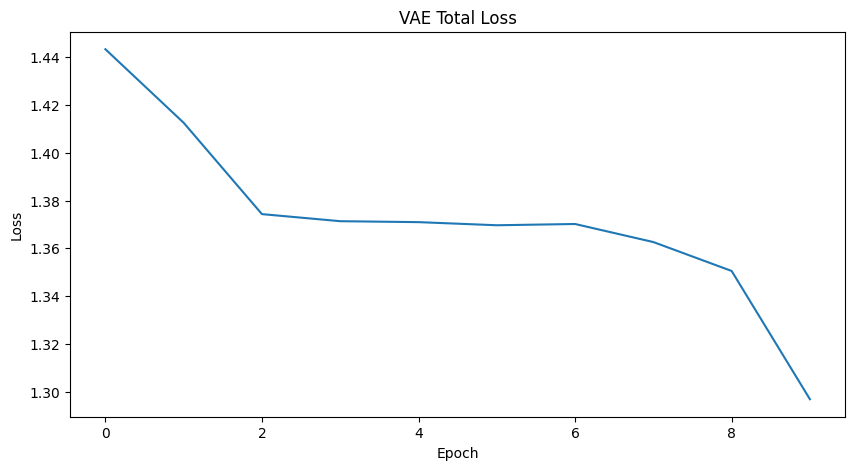

In [58]:
plt.figure(figsize=(10,5))

plt.plot(train_losses)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Total Loss')

plt.show()

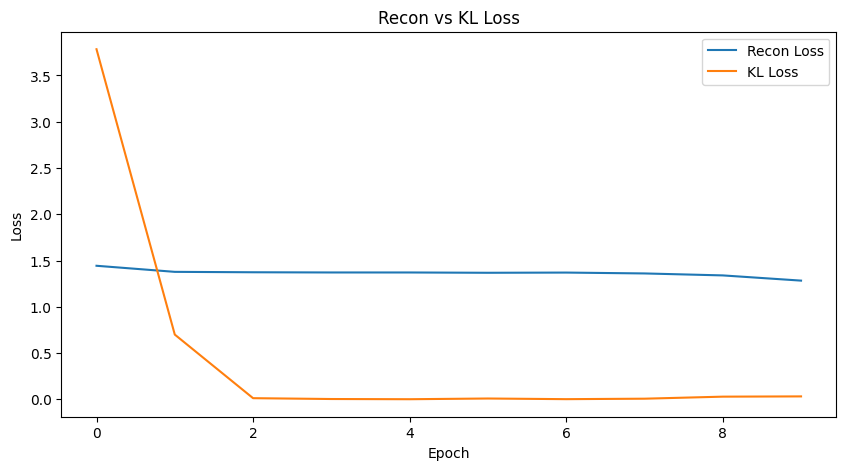

In [59]:
plt.figure(figsize=(10,5))

plt.plot(recon_losses, label='Recon Loss')
plt.plot(kl_losses, label='KL Loss')

plt.legend()

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Recon vs KL Loss')

plt.show()

In [60]:
torch.save(
    vae.state_dict(),
    '/content/drive/MyDrive/maestro/lstm_vae.pth'
)

In [61]:
vae.eval()

with torch.no_grad():

    z = torch.randn(1, 64).to(device)

    repeated = z.unsqueeze(1).repeat(
        1,
        128,
        1
    )

    decoded, _ = vae.decoder(repeated)

    output = vae.output_layer(decoded)

    probs = torch.sigmoid(output)

    generated = (probs > 0.35).float()

In [62]:
generated_roll = generated.squeeze(0).cpu().numpy()

In [63]:
def pianoroll_to_midi(
    piano_roll,
    output_path,
    fs=16
):

    midi = pretty_midi.PrettyMIDI()

    instrument = pretty_midi.Instrument(
        program=0
    )

    time_per_step = 1 / fs

    for pitch in range(88):

        active = False
        note_start = 0

        for t in range(len(piano_roll)):

            value = piano_roll[t, pitch]

            if value == 1 and not active:

                active = True

                note_start = t * time_per_step

            elif value == 0 and active:

                active = False

                note_end = t * time_per_step

                note = pretty_midi.Note(
                    velocity=80,
                    pitch=pitch + 21,
                    start=note_start,
                    end=note_end
                )

                instrument.notes.append(note)

    midi.instruments.append(instrument)

    midi.write(output_path)

In [64]:
pianoroll_to_midi(
    generated_roll,
    '/content/drive/MyDrive/maestro/vae_generated.mid'
)

In [65]:
vae.eval()

for i in range(8):

    with torch.no_grad():

        z = torch.randn(1, 64).to(device)

        repeated = z.unsqueeze(1).repeat(
            1,
            128,
            1
        )

        decoded, _ = vae.decoder(repeated)

        output = vae.output_layer(decoded)

        probs = torch.sigmoid(output)

        generated = (probs > 0.35).float()

    roll = generated.squeeze(0).cpu().numpy()

    pianoroll_to_midi(
        roll,
        f'/content/drive/MyDrive/maestro/vae_sample_{i}.mid'
    )

    print(f'Saved sample {i}')

Saved sample 0
Saved sample 1
Saved sample 2
Saved sample 3
Saved sample 4
Saved sample 5
Saved sample 6
Saved sample 7


In [66]:
sample1 = train_dataset[0].unsqueeze(0).to(device)
sample2 = train_dataset[1].unsqueeze(0).to(device)

In [67]:
vae.eval()

with torch.no_grad():

    _, mu1, _ = vae(sample1)

    _, mu2, _ = vae(sample2)

In [68]:
alphas = np.linspace(0, 1, 8)

for idx, alpha in enumerate(alphas):
    with torch.no_grad():
        z = (1 - alpha) * mu1 + alpha * mu2
        repeated = z.unsqueeze(1).repeat(1, 128, 1)
        decoded, _ = vae.decoder(repeated)
        output = vae.output_layer(decoded)
        probs = torch.sigmoid(output)
        generated = (probs > 0.2).float()

    roll = generated.squeeze(0).cpu().numpy()
    pianoroll_to_midi(roll, f'/content/drive/MyDrive/maestro/interpolation_{idx}.mid')
    print(f'Interpolation {idx} saved')

Interpolation 0 saved
Interpolation 1 saved
Interpolation 2 saved
Interpolation 3 saved
Interpolation 4 saved
Interpolation 5 saved
Interpolation 6 saved
Interpolation 7 saved


In [16]:
import numpy as np
import pretty_midi

def pitch_histogram(midi_path):
    midi = pretty_midi.PrettyMIDI(midi_path)

    histogram = np.zeros(12)
    total_notes = 0

    for instrument in midi.instruments:
        for note in instrument.notes:
            pitch_class = note.pitch % 12
            histogram[pitch_class] += 1
            total_notes += 1

    if total_notes > 0:
        histogram = histogram / total_notes

    return histogram

In [26]:
def pitch_histogram_similarity(real_midi, generated_midi):

    p = pitch_histogram(real_midi)
    q = pitch_histogram(generated_midi)

    distance = np.sum(np.abs(p - q))

    return distance

In [23]:
real_midi = "/content/drive/MyDrive/maestro/markov.mid"
generated_midi = "/content/drive/MyDrive/maestro/vae_generated.mid"

In [24]:
result = pitch_histogram_similarity(real_midi, generated_midi)
print("Pitch Histogram Distance:", result)

Pitch Histogram Distance: 0.8200000000000001


In [28]:
p = pitch_histogram(real_midi)
q = pitch_histogram(generated_midi)

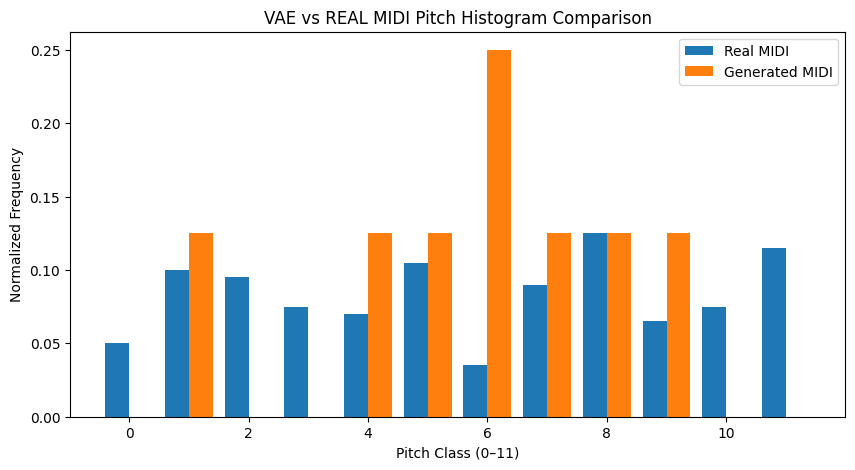

In [35]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(12)

plt.figure(figsize=(10,5))

plt.bar(x - 0.2, p, width=0.4, label="Real MIDI")
plt.bar(x + 0.2, q, width=0.4, label="Generated MIDI")

plt.xlabel("Pitch Class (0–11)")
plt.ylabel("Normalized Frequency")
plt.title("VAE vs REAL MIDI Pitch Histogram Comparison")
plt.legend()

plt.show()

In [71]:
real_file = sample_path

generated_file = '/content/drive/MyDrive/maestro/vae_sample_0.mid'

score = pitch_histogram_similarity(
    real_file,
    generated_file
)

print(score)

0.7368954014772457


In [72]:
def rhythm_diversity(midi_path):

    midi = pretty_midi.PrettyMIDI(midi_path)

    durations = []

    for instrument in midi.instruments:

        for note in instrument.notes:

            duration = note.end - note.start

            quantized = round(duration / 0.05) * 0.05

            durations.append(quantized)

    if len(durations) == 0:
        return 0

    unique_count = len(set(durations))

    total_notes = len(durations)

    return unique_count / total_notes

In [73]:
score = rhythm_diversity(
    generated_file
)

print(score)

0.5


In [74]:
def repetition_ratio(
    midi_path,
    n=4
):

    midi = pretty_midi.PrettyMIDI(midi_path)

    pitches = []

    for instrument in midi.instruments:

        notes = sorted(
            instrument.notes,
            key=lambda x: x.start
        )

        for note in notes:
            pitches.append(note.pitch)

    patterns = []

    for i in range(len(pitches) - n):

        pattern = tuple(
            pitches[i:i+n]
        )

        patterns.append(pattern)

    if len(patterns) == 0:
        return 0

    counts = {}

    for pattern in patterns:

        counts[pattern] = (
            counts.get(pattern, 0) + 1
        )

    repeated = 0

    for value in counts.values():

        if value > 1:
            repeated += 1

    return repeated / len(patterns)

In [75]:
score = repetition_ratio(
    generated_file
)

print(score)

0.0


In [76]:
def verify_midi(path):

    midi = pretty_midi.PrettyMIDI(path)

    total_notes = 0

    for instrument in midi.instruments:

        total_notes += len(
            instrument.notes
        )

    duration = midi.get_end_time()

    print('Notes:', total_notes)

    print('Duration:', duration)

In [77]:
verify_midi(generated_file)

Notes: 16
Duration: 0.5636363636363636


In [78]:
def random_music_generator(
    output_path,
    num_notes=200
):

    midi = pretty_midi.PrettyMIDI()

    instrument = pretty_midi.Instrument(
        program=0
    )

    current_time = 0

    for i in range(num_notes):

        pitch = np.random.randint(
            21,
            109
        )

        duration = np.random.choice(
            [0.25, 0.5, 1.0]
        )

        velocity = np.random.randint(
            60,
            100
        )

        note = pretty_midi.Note(
            velocity=velocity,
            pitch=pitch,
            start=current_time,
            end=current_time + duration
        )

        instrument.notes.append(note)

        current_time += duration

    midi.instruments.append(
        instrument
    )

    midi.write(output_path)

In [79]:
random_music_generator(
    '/content/drive/MyDrive/maestro/random_baseline.mid'
)

In [80]:
random_file = '/content/drive/MyDrive/maestro/random_baseline.mid'

print(
    pitch_histogram_similarity(
        real_file,
        random_file
    )
)

print(
    rhythm_diversity(
        random_file
    )
)

print(
    repetition_ratio(
        random_file
    )
)

0.27561591613056946
0.015
0.0


In [81]:
def extract_pitch_sequence(midi_path):

    midi = pretty_midi.PrettyMIDI(midi_path)

    pitches = []

    for instrument in midi.instruments:

        notes = sorted(
            instrument.notes,
            key=lambda x: x.start
        )

        for note in notes:
            pitches.append(note.pitch)

    return pitches

In [82]:
transition_counts = np.zeros((128, 128))

duration_pool = []

files = train_df['midi_filename'].tolist()[:200]

for file in files:

    path = os.path.join(
        DATASET_PATH,
        file
    )

    try:

        midi = pretty_midi.PrettyMIDI(path)

        pitches = []

        for instrument in midi.instruments:

            notes = sorted(
                instrument.notes,
                key=lambda x: x.start
            )

            for note in notes:

                pitches.append(note.pitch)

                duration_pool.append(
                    note.end - note.start
                )

        for i in range(len(pitches) - 1):

            current_pitch = pitches[i]

            next_pitch = pitches[i + 1]

            transition_counts[
                current_pitch,
                next_pitch
            ] += 1

    except:
        continue

In [83]:
transition_matrix = transition_counts.copy()

for i in range(128):

    row_sum = np.sum(
        transition_matrix[i]
    )

    if row_sum > 0:

        transition_matrix[i] /= row_sum

In [84]:
def generate_markov_music(
    output_path,
    num_notes=200
):

    midi = pretty_midi.PrettyMIDI()

    instrument = pretty_midi.Instrument(
        program=0
    )

    current_pitch = np.random.randint(
        21,
        109
    )

    current_time = 0

    for i in range(num_notes):

        probs = transition_matrix[
            current_pitch
        ]

        if np.sum(probs) == 0:

            next_pitch = np.random.randint(
                21,
                109
            )

        else:

            next_pitch = np.random.choice(
                np.arange(128),
                p=probs
            )

        duration = np.random.choice(
            duration_pool
        )

        note = pretty_midi.Note(
            velocity=80,
            pitch=int(next_pitch),
            start=current_time,
            end=current_time + duration
        )

        instrument.notes.append(note)

        current_time += duration

        current_pitch = next_pitch

    midi.instruments.append(
        instrument
    )

    midi.write(output_path)

In [85]:
generate_markov_music(
    '/content/drive/MyDrive/maestro/markov.mid'
)

In [86]:
markov_file = '/content/drive/MyDrive/maestro/markov.mid'

print(
    pitch_histogram_similarity(
        real_file,
        markov_file
    )
)

print(
    rhythm_diversity(
        markov_file
    )
)

print(
    repetition_ratio(
        markov_file
    )
)

0.2918251131760781
0.075
0.0
